# ANGEL

| | G_internal | G_combined |
|---|---|---|
| **Type** | Undirected, unweighted | Undirected, weighted (BC score) |
| **Edges** | Citation links only | Citations + bibliographic coupling |
| **CD input** | `graph_internal_2020.gpickle` | `graph_combined_2020.gpickle` |
| **ANGEL variant** | Overlapping community detection | Overlapping community detection (w/ weights) |

Note: ANGEL is used here to model overlap explicitly (multi-membership nodes).

In [7]:
import os, re, time, pickle, textwrap, warnings
os.environ['PYTHONHASHSEED'] = '0'
from collections import Counter, defaultdict
from concurrent.futures import ProcessPoolExecutor, as_completed
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import entropy as scipy_entropy
from sklearn.metrics import normalized_mutual_info_score, mutual_info_score
from cdlib import algorithms, NodeClustering, evaluation

GRAPH_DIR     = '../00_graph_construction/output/graphs'
INTERNAL_PATH = os.path.join(GRAPH_DIR, 'graph_internal_2020.gpickle')
COMBINED_PATH = os.path.join(GRAPH_DIR, 'graph_combined_2020.gpickle')

THRESHOLD      = 0.45
MIN_COMM_SIZE  = 4
FATE_MIN_SIZE  = 50
TOP_N_COMMS    = 20
TOP_K          = 5

## Graph loading

In [2]:
def load_graph(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

G_internal = load_graph(INTERNAL_PATH)
G_combined = load_graph(COMBINED_PATH)
G_internal_undir = G_internal.to_undirected()

for u, v, d in G_combined.edges(data=True):
    if 'weight' not in d:
        d['weight'] = 1.0

w = [d['weight'] for _, _, d in G_combined.edges(data=True)]

print(f"G_internal   {G_internal.number_of_nodes():>7,} nodes   {G_internal.number_of_edges():>8,} edges  (directed, unweighted)")
print(f"G_combined   {G_combined.number_of_nodes():>7,} nodes   {G_combined.number_of_edges():>8,} edges  "
      f"(undirected, weighted)  median_w={np.median(w):.3f}")

G_internal    55,078 nodes    217,925 edges  (directed, unweighted)
G_combined    58,627 nodes    590,157 edges  (undirected, weighted)  median_w=0.249


## Attribute statistics

In [3]:
_LEVEL_RE = {
    'macro': re.compile(r'^\d{2}\s'),
    'sub':   re.compile(r'^\d{4}\s'),
}

def parse_labels(val, level='sub'):
    """Split semicolon-separated FOS/SDG string into atomic labels."""
    if not val:
        return []
    parts = [p.strip() for p in str(val).split(';') if p.strip()]
    pattern = _LEVEL_RE.get(level)
    return [p for p in parts if pattern.match(p)] if pattern else parts

def _split_labels(raw_value):
    return [p.strip() for p in re.split(r';\s*', str(raw_value)) if p.strip()]

def _extract_l2(counter):
    l2 = Counter()
    for label, count in counter.items():
        if re.match(r'^\d{2}', label):
            l2[label[:2]] += count
    return l2

def compute_attr_stats(G, attributes=('FOS', 'SDG')):
    stats = {}
    for attr in attributes:
        counts = Counter()
        n_nodes = 0
        for _, data in G.nodes(data=True):
            val = data.get(attr)
            if not val:
                continue
            n_nodes += 1
            counts.update(_split_labels(val))
        stats[attr] = {'counts': counts, 'n_nodes': n_nodes}
        if attr == 'FOS':
            stats['FOS_L2'] = {'counts': _extract_l2(counts), 'n_nodes': n_nodes}
    return stats

def compare_attr_stats(stats_int, stats_comb, key):
    n_i = stats_int[key]['n_nodes']
    n_c = stats_comb[key]['n_nodes']
    all_labels = sorted(set(stats_int[key]['counts']) | set(stats_comb[key]['counts']))
    rows = []
    for label in all_labels:
        ci = stats_int[key]['counts'].get(label, 0)
        cc = stats_comb[key]['counts'].get(label, 0)
        rows.append({
            'label': label,
            'int_cnt': ci,  'int_pct': ci / n_i * 100 if n_i else 0,
            'comb_cnt': cc, 'comb_pct': cc / n_c * 100 if n_c else 0,
        })
    return pd.DataFrame(rows)

s_int  = compute_attr_stats(G_internal)
s_comb = compute_attr_stats(G_combined)

pd.concat([
    compare_attr_stats(s_int, s_comb, 'FOS').assign(level='detail'),
    compare_attr_stats(s_int, s_comb, 'FOS_L2').assign(level='L2'),
], ignore_index=True).to_csv('FOS_stats.csv', index=False)

compare_attr_stats(s_int, s_comb, 'SDG') \
    .sort_values('int_cnt', ascending=False) \
    .to_csv('SDG_stats.csv', index=False)

print('FOS_stats.csv  SDG_stats.csv  created')

FOS_stats.csv  SDG_stats.csv  created


## ANGEL - Parameter calibration

ANGEL (Rossetti et al., 2017) depends strongly on `threshold` and `min_community_size`.

### Sweep strategy

We sweep threshold and minimum size, then select a stable regime balancing:

1. overlap signal (enough bridge nodes)
2. partition quality (modularity overlap, conductance)
3. structural plausibility (limited micro-communities)

Chosen operating point: `threshold=0.65`, `min_community_size=6`.

In [4]:
ELBOW_CSV = 'angel_elbow_sweep.csv'
ELBOW_RUNS_CSV = 'angel_elbow_sweep_runs.csv'
THRESHOLDS_SWEEP = [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
MIN_SIZES = list(range(4, 8))
N_WORKERS = 10
N_ITER = 1
FORCE_RECOMPUTE_SWEEP = False

_WORKER_GRAPHS = {}

def _get_worker_graphs(int_path, comb_path):
    key = (int_path, comb_path)
    if key not in _WORKER_GRAPHS:
        import pickle
        with open(int_path, 'rb') as f:
            g_int = pickle.load(f).to_undirected()
        with open(comb_path, 'rb') as f:
            g_comb = pickle.load(f)
        _WORKER_GRAPHS[key] = (g_int, g_comb)
    return _WORKER_GRAPHS[key]


def _sweep_worker(args):
    """Run ANGEL for one (threshold, min_size, run_id) on both graphs."""
    int_path, comb_path, thr, min_size, run_id = args
    import time
    import numpy as np
    from collections import Counter, defaultdict
    from cdlib import algorithms, evaluation

    G_int, G_comb = _get_worker_graphs(int_path, comb_path)

    def _metrics(cl, G, all_nodes):
        mem = Counter(n for c in cl.communities for n in c)
        covered = set(mem)
        overlapping = {n for n, k in mem.items() if k > 1}
        sizes = [len(c) for c in cl.communities]

        avg_memberships = (np.mean([mem[n] for n in overlapping])
                           if overlapping else 0.0)
        mod_ol = evaluation.modularity_overlap(G, cl).score
        cond = evaluation.conductance(G, cl).score
        micro_frac = sum(1 for s in sizes if s < 5) / len(sizes) if sizes else 0.0

        return {
            'n_communities': len(cl.communities),
            'coverage': len(covered) / len(all_nodes) if all_nodes else 0.0,
            'overlap_rate': len(overlapping) / len(covered) if covered else 0.0,
            'n_overlapping': len(overlapping),
            'avg_memberships': avg_memberships,
            'avg_comm_size': float(np.mean(sizes)) if sizes else 0.0,
            'median_comm_size': float(np.median(sizes)) if sizes else 0.0,
            'modularity_overlap': mod_ol,
            'conductance': cond,
            'micro_frac': micro_frac,
        }

    def _crisp_communities(cl, G):
        # Build a complete crisp cover: uncovered nodes become singleton communities,
        # ensuring all runs cover the same node set for Omega comparisons.
        node_to_comms = cl.to_node_community_map()
        comm_sets = [set(c) for c in cl.communities]
        final = {}
        for node, comms in node_to_comms.items():
            if len(comms) == 1:
                final[node] = comms[0]
            else:
                neigh = set(G.neighbors(node))
                final[node] = max(comms, key=lambda cid: len(neigh & comm_sets[cid]))

        clean = defaultdict(list)
        for node, cid in final.items():
            clean[cid].append(node)

        crisp = list(clean.values())
        covered = set(final)
        for node in G.nodes:
            if node not in covered:
                crisp.append([node])
        return crisp

    records = []
    for G, gname in [(G_int, 'G_internal'), (G_comb, 'G_combined')]:
        t0 = time.time()
        cl = algorithms.angel(G, threshold=thr, min_community_size=min_size)
        m = _metrics(cl, G, set(G.nodes))
        records.append({
            'graph': gname,
            'min_size': min_size,
            'threshold': thr,
            'run_id': run_id,
            **m,
            'elapsed_s': round(time.time() - t0, 1),
            'crisp_communities': _crisp_communities(cl, G),
        })
    return records


def _medoid_from_runs(df_runs, graph_map):
    medoid_rows = []

    keys = ['graph', 'min_size', 'threshold']
    for key_vals, grp in df_runs.groupby(keys, sort=False):
        gname, _, _ = key_vals
        rows = grp.to_dict('records')
        n = len(rows)

        partitions = [
            NodeClustering(r['crisp_communities'], graph=graph_map[gname], method_name='angel_crisp')
            for r in rows
        ]

        omega_matrix = np.eye(n)
        pairwise_scores = []
        for i in range(n):
            for j in range(i + 1, n):
                try:
                    s = evaluation.omega(partitions[i], partitions[j]).score
                except ValueError:
                    # Fallback on common covered nodes, in case a legacy run file has non-complete cover.
                    nodes_i = {u for c in partitions[i].communities for u in c}
                    nodes_j = {u for c in partitions[j].communities for u in c}
                    common = nodes_i & nodes_j
                    if len(common) < 2:
                        s = 1.0
                    else:
                        comm_i = [list(set(c) & common) for c in partitions[i].communities]
                        comm_j = [list(set(c) & common) for c in partitions[j].communities]
                        comm_i = [c for c in comm_i if len(c) > 0]
                        comm_j = [c for c in comm_j if len(c) > 0]
                        p_i = NodeClustering(comm_i, graph=None, method_name='angel_crisp_common')
                        p_j = NodeClustering(comm_j, graph=None, method_name='angel_crisp_common')
                        s = evaluation.omega(p_i, p_j).score

                omega_matrix[i, j] = s
                omega_matrix[j, i] = s
                pairwise_scores.append(s)

        if n > 1:
            mean_omega = (omega_matrix.sum(axis=1) - 1.0) / (n - 1)
        else:
            mean_omega = np.array([1.0])

        medoid_idx = int(np.argmax(mean_omega))
        medoid = rows[medoid_idx].copy()
        medoid['medoid_run_id'] = medoid.pop('run_id')
        medoid['n_iter'] = n
        medoid['omega_medoid_mean'] = float(mean_omega[medoid_idx])
        medoid['omega_pair_mean'] = float(np.mean(pairwise_scores)) if pairwise_scores else 1.0
        medoid['omega_pair_std'] = float(np.std(pairwise_scores)) if pairwise_scores else 0.0
        medoid.pop('crisp_communities', None)
        medoid_rows.append(medoid)

    out = pd.DataFrame(medoid_rows)
    return out.sort_values(['graph', 'min_size', 'threshold']).reset_index(drop=True)


need_recompute = True
if os.path.exists(ELBOW_CSV) and not FORCE_RECOMPUTE_SWEEP:
    df_sweep = pd.read_csv(ELBOW_CSV)
    has_expected_schema = {'n_iter', 'omega_medoid_mean', 'medoid_run_id'}.issubset(df_sweep.columns)
    if has_expected_schema and (df_sweep['n_iter'].min() >= N_ITER):
        need_recompute = False
        df_sweep = df_sweep.sort_values(['graph', 'min_size', 'threshold']).reset_index(drop=True)
        print(f"Loaded {len(df_sweep)} medoid records from {ELBOW_CSV}")
    else:
        print(f"Existing {ELBOW_CSV} is not compatible with N_ITER={N_ITER}. Recomputing...")

if need_recompute:
    args_list = [
        (INTERNAL_PATH, COMBINED_PATH, thr, ms, run_id)
        for ms in MIN_SIZES
        for thr in THRESHOLDS_SWEEP
        for run_id in range(1, N_ITER + 1)
    ]

    print(
        f"Running {len(args_list)} tasks "
        f"({len(THRESHOLDS_SWEEP)} thresholds x {len(MIN_SIZES)} min_sizes x {N_ITER} iter x 2 graphs)..."
    )

    all_records = []
    with ProcessPoolExecutor(max_workers=N_WORKERS) as pool:
        futures = {pool.submit(_sweep_worker, a): a for a in args_list}
        for i, fut in enumerate(as_completed(futures), 1):
            all_records.extend(fut.result())
            if i % 25 == 0:
                print(f"  {i}/{len(args_list)} task completati")

    df_runs = pd.DataFrame(all_records)
    df_runs_no_part = df_runs.drop(columns=['crisp_communities'])
    df_runs_no_part.to_csv(ELBOW_RUNS_CSV, index=False)

    graph_map = {
        'G_internal': G_internal_undir,
        'G_combined': G_combined,
    }
    df_sweep = _medoid_from_runs(df_runs, graph_map)

    df_sweep.to_csv(ELBOW_CSV, index=False)
    print(f"Saved run-level records to {ELBOW_RUNS_CSV}: {len(df_runs_no_part)} rows")
    print(f"Saved medoid sweep to {ELBOW_CSV}: {len(df_sweep)} rows")

Running 36 tasks (9 thresholds x 4 min_sizes x 1 iter x 2 graphs)...
  25/36 task completati
Saved run-level records to angel_elbow_sweep_runs.csv: 72 rows
Saved medoid sweep to angel_elbow_sweep.csv: 72 rows


### Parameter selection rationale

The sweep is used to identify the last stable point before fragmentation.

- Too low threshold: low overlap signal
- Too high threshold: many small/noisy communities and quality degradation
- `min_community_size=6`: filters micro-clusters while preserving interpretable structure

For reproducibility, the selected pair is propagated to all downstream analyses.

Top-10 configurazioni robuste (pre-screen):
 threshold  min_size  dist_to_ideal  maximin  utility  wc_modularity_overlap  wc_coverage  wc_overlap_rate  wc_omega_medoid_mean  wc_conductance  wc_micro_frac  wc_omega_pair_std
    0.4500         4         1.0063   0.0392   0.6197                 0.2260       0.6442           0.0884                1.0000          0.3313         0.1080             0.0000
    0.5500         5         1.0069   0.1310   0.6194                 0.1641       0.6035           0.1268                1.0000          0.3927         0.0000             0.0000
    0.5000         5         1.0374   0.0967   0.6079                 0.1649       0.6034           0.1125                1.0000          0.3948         0.0000             0.0000
    0.4000         4         1.0396   0.0000   0.6071                 0.2339       0.6446           0.0720                1.0000          0.3195         0.1046             0.0000
    0.4500         5         1.0434   0.0579   0.6056        

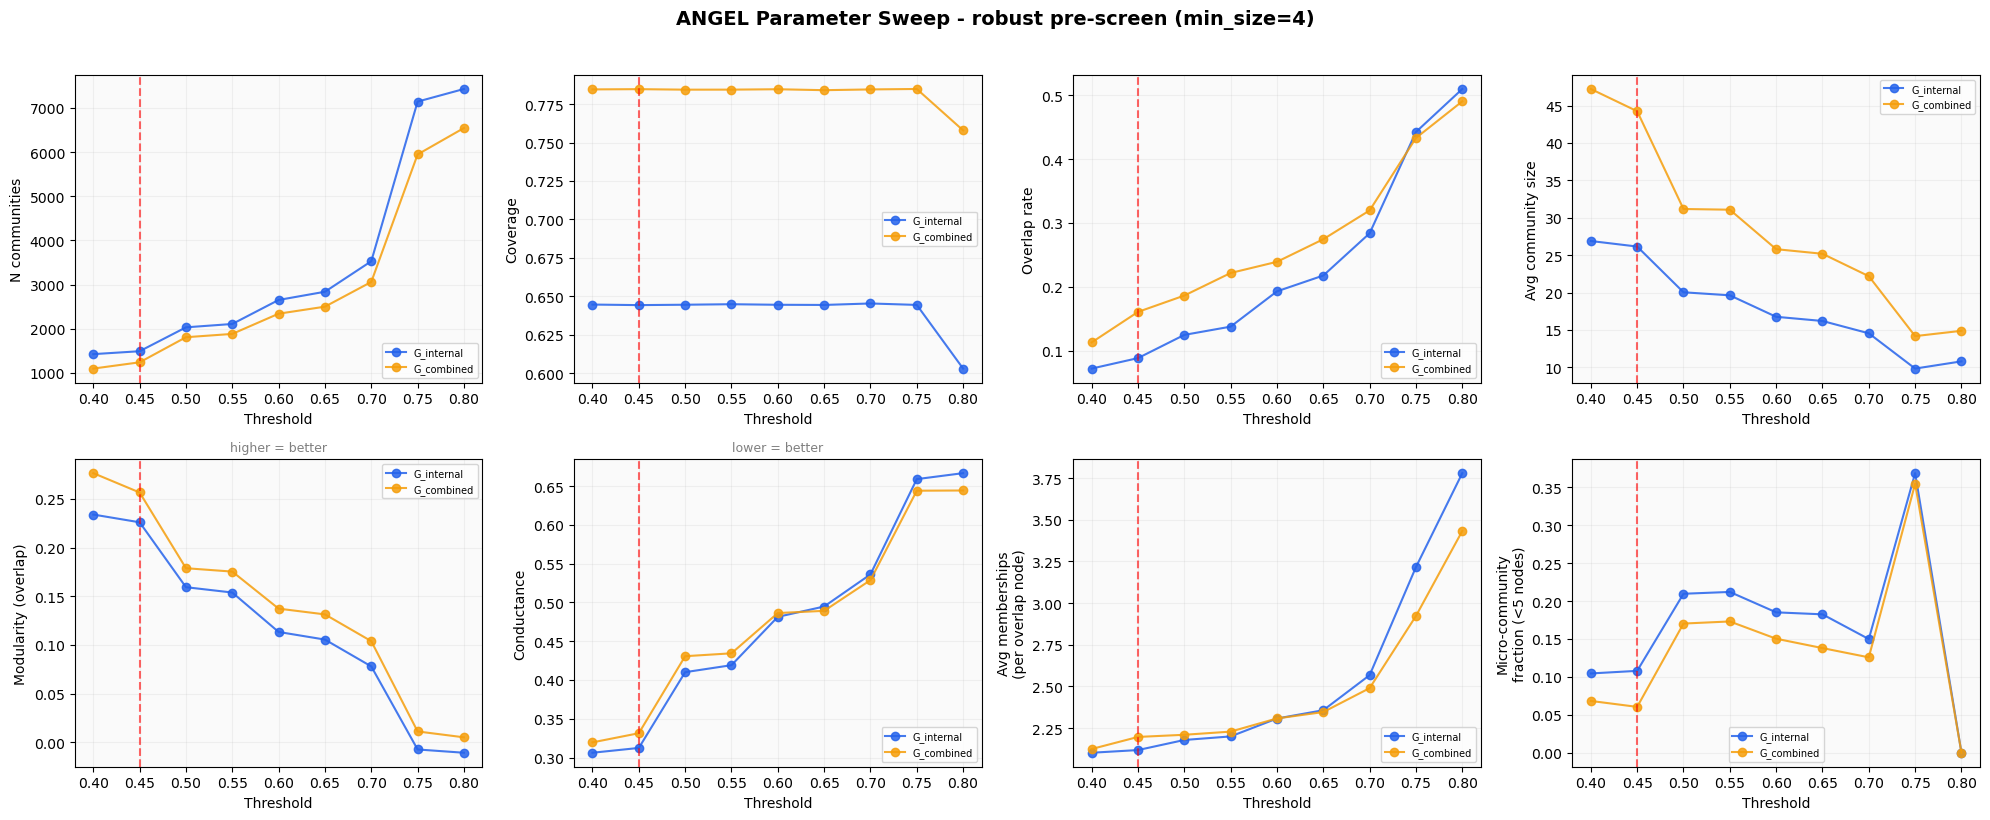

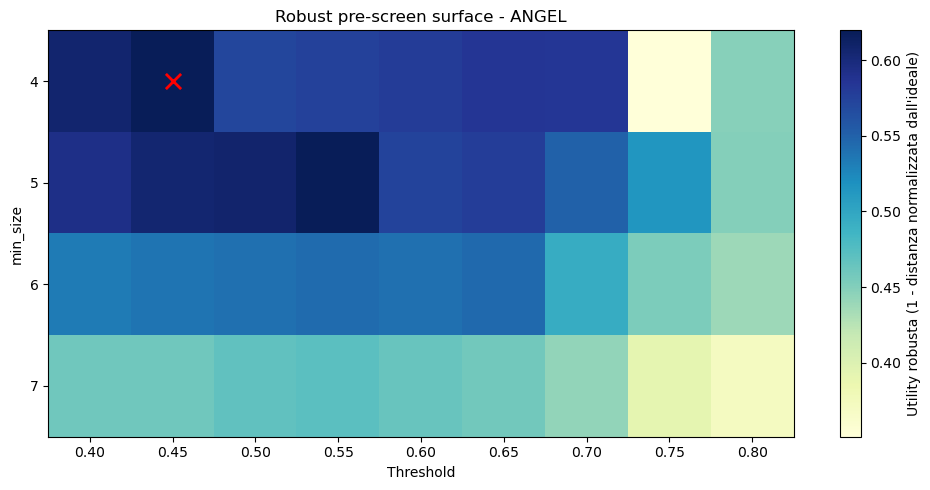

In [5]:
metrics = [
    ('n_communities',      'N communities',                        None),
    ('coverage',           'Coverage',                              None),
    ('overlap_rate',       'Overlap rate',                          None),
    ('avg_comm_size',      'Avg community size',                    None),
    ('modularity_overlap', 'Modularity (overlap)',                  'higher = better'),
    ('conductance',        'Conductance',                           'lower = better'),
    ('avg_memberships',    'Avg memberships\n(per overlap node)',  None),
    ('micro_frac',         'Micro-community\nfraction (<5 nodes)', None),
]

if 'omega_medoid_mean' not in df_sweep.columns:
    raise ValueError(
        'df_sweep non contiene metriche Omega del medoid. '
        'Riesegui prima la cella di sweep con N_ITER > 1.'
    )

benefit_metrics = ['modularity_overlap', 'coverage', 'overlap_rate', 'omega_medoid_mean']
cost_metrics = ['conductance', 'micro_frac', 'omega_pair_std']
all_metrics = benefit_metrics + cost_metrics

required = set(['graph', 'threshold', 'min_size'] + all_metrics)
missing = required - set(df_sweep.columns)
if missing:
    raise ValueError(f'df_sweep missing columns: {sorted(missing)}')

# Pre-screen robusto senza pesi manuali: aggregazione worst-case tra i due grafi.
robust = (
    df_sweep.pivot_table(
        index=['threshold', 'min_size'],
        columns='graph',
        values=all_metrics,
        aggfunc='mean'
    )
)
robust.columns = [f'{m}_{g}' for m, g in robust.columns]
robust = robust.reset_index()

for m in benefit_metrics:
    robust[f'wc_{m}'] = robust[[f'{m}_G_internal', f'{m}_G_combined']].min(axis=1)
for m in cost_metrics:
    robust[f'wc_{m}'] = robust[[f'{m}_G_internal', f'{m}_G_combined']].max(axis=1)


def _norm_max(x):
    lo, hi = x.min(), x.max()
    if hi <= lo:
        return pd.Series(1.0, index=x.index)
    return (x - lo) / (hi - lo)


def _norm_min(x):
    lo, hi = x.min(), x.max()
    if hi <= lo:
        return pd.Series(1.0, index=x.index)
    return (hi - x) / (hi - lo)


for m in benefit_metrics:
    robust[f'n_{m}'] = _norm_max(robust[f'wc_{m}'])
for m in cost_metrics:
    robust[f'n_{m}'] = _norm_min(robust[f'wc_{m}'])

norm_cols = [f'n_{m}' for m in all_metrics]
robust['maximin'] = robust[norm_cols].min(axis=1)
robust['dist_to_ideal'] = np.linalg.norm(robust[norm_cols].to_numpy() - 1.0, axis=1)
robust['utility'] = 1.0 - robust['dist_to_ideal'] / np.sqrt(len(norm_cols))

# Punto preliminare coerente con la logica Pareto/knee (closest-to-ideal + maximin tie-break)
pre = robust.sort_values(['dist_to_ideal', 'maximin'], ascending=[True, False]).iloc[0]
pre_thr = float(pre['threshold'])
pre_ms = int(pre['min_size'])

print('Top-10 configurazioni robuste (pre-screen):')
print(
    robust.sort_values(['dist_to_ideal', 'maximin'], ascending=[True, False])
          .head(10)[
              ['threshold', 'min_size', 'dist_to_ideal', 'maximin', 'utility']
              + [f'wc_{m}' for m in all_metrics]
          ]
          .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)
print(f"\nPreliminary robust point: threshold={pre_thr:.2f}, min_size={pre_ms}")

# Vista metrica su threshold fissando min_size preliminare
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle(
    f'ANGEL Parameter Sweep - robust pre-screen (min_size={pre_ms})',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

for ax, (col, ylabel, note) in zip(axes.ravel(), metrics):
    for gname, color in [('G_internal', '#2563EB'), ('G_combined', '#F59E0B')]:
        sub = df_sweep[(df_sweep['graph'] == gname) & (df_sweep['min_size'] == pre_ms)]
        sub = sub.sort_values('threshold')
        ax.plot(sub['threshold'], sub[col], 'o-', color=color, label=gname, alpha=0.85)
    ax.axvline(pre_thr, ls='--', color='red', alpha=0.6)
    ax.set_xlabel('Threshold')
    ax.set_ylabel(ylabel)
    if note:
        ax.set_title(note, fontsize=9, color='grey')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.15)
    ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.show()

# Heatmap utility robusta su tutta la griglia
piv = robust.pivot(index='min_size', columns='threshold', values='utility').sort_index()

plt.figure(figsize=(10, 5))
im = plt.imshow(piv.values, aspect='auto', cmap='YlGnBu')
plt.colorbar(im, label='Utility robusta (1 - distanza normalizzata dall\'ideale)')
plt.xticks(range(len(piv.columns)), [f'{x:.2f}' for x in piv.columns])
plt.yticks(range(len(piv.index)), [str(int(x)) for x in piv.index])
plt.xlabel('Threshold')
plt.ylabel('min_size')
plt.title('Robust pre-screen surface - ANGEL')

px = list(piv.columns).index(pre_thr)
py = list(piv.index).index(pre_ms)
plt.scatter([px], [py], color='red', s=120, marker='x', linewidths=2)

plt.tight_layout()
plt.show()

## ANGEL runs

In [8]:
def angel_coverage_stats(cl, all_nodes):
    """Coverage and overlap statistics for an ANGEL NodeClustering."""
    membership = Counter(node for comm in cl.communities for node in comm)
    covered = set(membership)
    overlapping = {n for n, cnt in membership.items() if cnt > 1}
    return {
        'coverage': len(covered) / len(all_nodes) if all_nodes else 0.0,
        'overlap_rate': len(overlapping) / len(covered) if covered else 0.0,
        'n_communities': len(cl.communities),
        'n_overlapping': len(overlapping),
    }

def run_angel(G, graph_name, threshold=THRESHOLD, min_community_size=MIN_COMM_SIZE):
    """Run ANGEL once and return (NodeClustering, stats dict)."""
    t0 = time.time()
    all_nodes = set(G.nodes)
    print(f'--- ANGEL run: {graph_name} ---')
    print(f'    threshold={threshold}  min_size={min_community_size}')

    cl = algorithms.angel(G, threshold=threshold, min_community_size=min_community_size)
    cov = angel_coverage_stats(cl, all_nodes)
    mod_ol = evaluation.modularity_overlap(G, cl).score
    cond = evaluation.conductance(G, cl).score

    stats = {**cov, 'mod_overlap': mod_ol, 'conductance': cond}

    print(f'    Communities : {cov["n_communities"]:,}')
    print(f'    Coverage    : {cov["coverage"]:.2%}')
    print(f'    Overlap rate: {cov["overlap_rate"]:.2%}  ({cov["n_overlapping"]:,} nodes in >=2 comms)')
    print(f'    Mod. overlap: {mod_ol:.4f}')
    print(f'    Conductance : {cond:.4f}')
    print(f'    Elapsed     : {time.time()-t0:.1f}s\n')

    return cl, stats

In [9]:
angel_internal, angel_internal_stats = run_angel(
    G_internal_undir, 'G_internal undirected'
)

--- ANGEL run: G_internal undirected ---
    threshold=0.45  min_size=4
    Communities : 1,494
    Coverage    : 64.42%
    Overlap rate: 8.98%  (3,185 nodes in >=2 comms)
    Mod. overlap: 0.2258
    Conductance : 0.3143
    Elapsed     : 15.5s



In [10]:
angel_combined, angel_combined_stats = run_angel(
    G_combined, 'G_combined'
)

--- ANGEL run: G_combined ---
    threshold=0.45  min_size=4
    Communities : 1,245
    Coverage    : 78.46%
    Overlap rate: 15.42%  (7,094 nodes in >=2 comms)
    Mod. overlap: 0.2556
    Conductance : 0.3315
    Elapsed     : 132.1s



### Coverage and overlap statistics

Unlike Leiden and InfoMap, ANGEL can:
- leave nodes uncovered
- assign one node to multiple communities

These metrics are ANGEL-specific and should be interpreted jointly with partition quality.

In [11]:
def print_coverage_comparison(stats_int, stats_comb):
    rows = []
    for stats, graph in [(stats_int, 'G_internal'), (stats_comb, 'G_combined')]:
        rows.append({'Graph': graph,
                     'Communities': stats['n_communities'],
                     'Coverage': f"{stats['coverage']:.1%}",
                     'Overlap rate': f"{stats['overlap_rate']:.1%}",
                     'Bridge nodes': stats['n_overlapping'],
                     'Mod. Overlap': f"{stats['mod_overlap']:.4f}",
                     'Conductance': f"{stats['conductance']:.4f}"})
    print(pd.DataFrame(rows).set_index('Graph').to_string())

print_coverage_comparison(angel_internal_stats, angel_combined_stats)

            Communities Coverage Overlap rate  Bridge nodes Mod. Overlap Conductance
Graph                                                                               
G_internal         1494    64.4%         9.0%          3185       0.2258      0.3143
G_combined         1245    78.5%        15.4%          7094       0.2556      0.3315


Interpretation guideline:

- Compare coverage and overlap rate between internal and combined graphs.
- Increased overlap suggests more boundary nodes (bridge candidates).
- Evaluate together with modularity overlap and conductance to avoid over-interpreting noisy overlap.

## Semantic profile - Fields of Study (FOS)

For the top `TOP_N_COMMS` communities, we extract the `TOP_K` most frequent FOS labels.
Cell color encodes label share within each community.

FOS values are split on `;` and filtered to 4-digit sub-discipline codes (`level='sub'`, e.g. `0302 clinical medicine`).
This avoids composite strings that would distort frequency and purity metrics.

In [25]:
def extract_semantic_topk(partition, G, attr='FOS', level='sub',
                          top_n=TOP_N_COMMS, top_k=TOP_K):
    """Top-K most frequent labels per community for the largest top_n communities."""
    communities = sorted(partition.communities, key=len, reverse=True)[:top_n]
    rows = []
    for rank, comm in enumerate(communities, 1):
        counter = Counter()
        for node in comm:
            counter.update(parse_labels(G.nodes[node].get(attr), level=level))
        total = sum(counter.values())
        top_terms = counter.most_common(top_k)
        top_terms += [('N/A', 0)] * (top_k - len(top_terms))
        for pos, (term, cnt) in enumerate(top_terms, 1):
            rows.append({
                'CommunityRank': rank, 'CommunitySize': len(comm),
                'Position': pos, 'Term': term,
                'Count': cnt, 'Share': cnt / total if total else 0,
            })
    return pd.DataFrame(rows)


def plot_semantic_topk(df_int, df_comb, semantic_name='FOS', cmap='YlGnBu'):
    """Side-by-side heatmap of top-K labels per community."""
    top_k = int(df_int['Position'].max())

    def _build_matrix(df):
        comms = sorted(df['CommunityRank'].unique())
        val_mat = np.zeros((len(comms), top_k))
        lbl_mat = [['' for _ in range(top_k)] for _ in range(len(comms))]
        ylabels = []
        for i, c in enumerate(comms):
            rows = df[df['CommunityRank'] == c].sort_values('Position')
            ylabels.append(f"C{c} (n={int(rows['CommunitySize'].iloc[0])})")
            for _, r in rows.iterrows():
                j = int(r['Position']) - 1
                val_mat[i, j] = r['Share']
                term = textwrap.shorten(str(r['Term']), width=24, placeholder='...')
                lbl_mat[i][j] = f"{term}\n{int(r['Count'])} ({r['Share']*100:.1f}%)"
        return val_mat, lbl_mat, ylabels

    mat_i, lbl_i, y_i = _build_matrix(df_int)
    mat_c, lbl_c, y_c = _build_matrix(df_comb)
    vmax = max(mat_i.max(), mat_c.max(), 1e-9)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
    for ax, mat, lbls, ylabs, title in [
        (axes[0], mat_i, lbl_i, y_i, f'ANGEL {semantic_name} — G_internal'),
        (axes[1], mat_c, lbl_c, y_c, f'ANGEL {semantic_name} — G_combined'),
    ]:
        im = ax.imshow(mat, aspect='auto', cmap=cmap, vmin=0, vmax=vmax)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xticks(range(top_k))
        ax.set_xticklabels([f'Top {i+1}' for i in range(top_k)])
        ax.set_yticks(range(len(ylabs)))
        ax.set_yticklabels(ylabs, fontsize=9)
        ax.set_xlabel('Label rank within community')
        ax.set_ylabel('Community')
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                ax.text(j, i, lbls[i][j], ha='center', va='center',
                        fontsize=7.5, color='black')
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9,
                 label='Label share within community')
    plt.show()

In [26]:
df_fos_int  = extract_semantic_topk(angel_internal, G_internal_undir, attr='FOS', level='sub')
df_fos_comb = extract_semantic_topk(angel_combined, G_combined,       attr='FOS', level='sub')

df_fos_l2_int  = extract_semantic_topk(angel_internal, G_internal_undir, attr='FOS', level='macro')
df_fos_l2_comb = extract_semantic_topk(angel_combined, G_combined,       attr='FOS', level='macro')

df_sdg_int  = extract_semantic_topk(angel_internal, G_internal_undir, attr='SDG', level='all')
df_sdg_comb = extract_semantic_topk(angel_combined, G_combined,       attr='SDG', level='all')

## Size distribution

A compact two-panel view highlights structural differences between `G_internal` and `G_combined`:
- rank-size curve on log-log axes
- cumulative node coverage across ranked communities

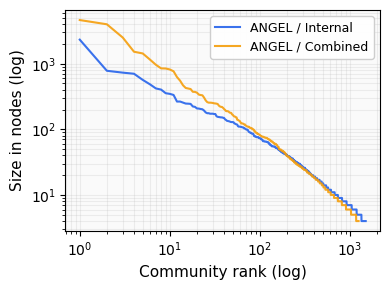


SIZE DISTRIBUTION SUMMARY
           Graph  n_comms  min  max mean median cov_10 cov_50 cov_80 cov_95  k_50%  k_80%  k_95%
ANGEL / Internal     1494    4 2325 26.1    9.0  18.2%  36.8%  44.9%  48.0%    106    475   1091
ANGEL / Combined     1245    4 4626 43.6   10.0  34.5%  56.1%  63.0%  65.6%     34    243    772

Legend:
  n_comms: number of communities
  min/max/mean/median: community size statistics
  cov_K: fraction of nodes covered by top-K communities
  k_XX%: number of communities needed to reach XX% coverage


{'ANGEL / Internal': {'n': 1494,
  'min': 4,
  'max': 2325,
  'mean': 26.133868808567605,
  'median': 9.0,
  'coverage': {10: 0.1822815285319127,
   50: 0.368302428029915,
   80: 0.4491599221391251,
   95: 0.4798944780247925},
  'nodes_for_thr': {0.5: 106, 0.8: 475, 0.95: 1091}},
 'ANGEL / Combined': {'n': 1245,
  'min': 4,
  'max': 4626,
  'mean': 43.6008032128514,
  'median': 10.0,
  'coverage': {10: 0.34458301862461543,
   50: 0.5610412099552347,
   80: 0.6301051894699998,
   95: 0.6559696405872926},
  'nodes_for_thr': {0.5: 34, 0.8: 243, 0.95: 772}}}

In [28]:
def plot_size_distribution(partition_a, label_a, partition_b, label_b,
                           color_a='#2563EB', color_b='#F59E0B',
                           title='', thresholds=(0.50, 0.80, 0.95),
                           include_curves=False):
    """Rank-size plot + compact tabular summary with 10/50/80/95 coverage."""

    def _sizes(partition):
        sizes = sorted((len(c) for c in partition.communities), reverse=True)
        if not sizes:
            raise ValueError('Partition has no communities.')
        return np.asarray(sizes, dtype=float)

    def _summary(arr):
        cov = np.cumsum(arr) / arr.sum()
        summary = {
            'n': len(arr),
            'min': int(arr.min()),
            'max': int(arr.max()),
            'mean': float(arr.mean()),
            'median': float(np.median(arr)),
            'coverage': {k: float(arr[:min(k, len(arr))].sum() / arr.sum())
                         for k in (10, 50, 80, 95)},
            'nodes_for_thr': {
                thr: int(np.searchsorted(cov, thr, side='left') + 1)
                for thr in thresholds
            },
        }
        if include_curves:
            summary['cov'] = cov
        return summary, cov

    sizes_a = _sizes(partition_a)
    sizes_b = _sizes(partition_b)
    stats_a, cov_a = _summary(sizes_a)
    stats_b, cov_b = _summary(sizes_b)

    fig, ax = plt.subplots(figsize=(4, 3))
    rank_a = np.arange(1, len(sizes_a) + 1)
    rank_b = np.arange(1, len(sizes_b) + 1)

    ax.plot(rank_a, sizes_a, color=color_a, lw=1.5, alpha=0.9, label=label_a)
    ax.plot(rank_b, sizes_b, color=color_b, lw=1.5, alpha=0.9, label=label_b)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Community rank (log)', fontsize=11)
    ax.set_ylabel('Size in nodes (log)', fontsize=11)
    ax.grid(True, which='both', alpha=0.2)
    ax.set_facecolor('#FAFAFA')
    ax.legend(fontsize=9, loc='upper right', framealpha=0.95)

    plt.tight_layout()
    plt.show()

    table_data = []
    for label, stats in ((label_a, stats_a), (label_b, stats_b)):
        row = {
            'Graph': label,
            'n_comms': stats['n'],
            'min': stats['min'],
            'max': stats['max'],
            'mean': f"{stats['mean']:.1f}",
            'median': f"{stats['median']:.1f}",
            'cov_10': f"{stats['coverage'][10]:.1%}",
            'cov_50': f"{stats['coverage'][50]:.1%}",
            'cov_80': f"{stats['coverage'][80]:.1%}",
            'cov_95': f"{stats['coverage'][95]:.1%}",
            'k_50%': stats['nodes_for_thr'][0.50],
            'k_80%': stats['nodes_for_thr'][0.80],
            'k_95%': stats['nodes_for_thr'][0.95],
        }
        table_data.append(row)

    df_summary = pd.DataFrame(table_data)

    print("\nSIZE DISTRIBUTION SUMMARY")
    print("=" * 130)
    print(df_summary.to_string(index=False))
    print("=" * 130)
    print("\nLegend:")
    print("  n_comms: number of communities")
    print("  min/max/mean/median: community size statistics")
    print("  cov_K: fraction of nodes covered by top-K communities")
    print("  k_XX%: number of communities needed to reach XX% coverage")

    return {
        label_a: stats_a,
        label_b: stats_b,
    }


plot_size_distribution(
    angel_internal, 'ANGEL / Internal',
    angel_combined, 'ANGEL / Combined',
    title='ANGEL — Community Size Distribution'
)

## Bridge paper analysis

A paper in >=2 ANGEL communities is a bridge candidate.
To reduce structural artifacts, classify candidates by neighbour dominance across memberships.

| Dominance | Classification |
|---|---|
| >= 85% | likely artefact (skewed to one community) |
| < 85% | true bridge (distributed neighbourhood) |

In [29]:
def extract_overlapping_papers(angel_clustering):
    """Return {node: [comm_ids]} for nodes in >=2 communities."""
    node_to_comms = angel_clustering.to_node_community_map()
    return dict(sorted(
        {n: sorted(c) for n, c in node_to_comms.items() if len(c) > 1}.items(),
        key=lambda x: len(x[1]), reverse=True
    ))


def analyze_bridge_topology(top_candidates, angel_clustering, G):
    """Classify bridge papers: true bridge vs likely artefact."""
    comm_sets = [set(c) for c in angel_clustering.communities]
    rows = []
    for node_id, comm_ids in top_candidates:
        neighbours = set(G.neighbors(node_id))
        comm_neigh = {cid: len(neighbours & comm_sets[cid]) for cid in comm_ids}
        total_tracked = sum(comm_neigh.values())
        if total_tracked == 0:
            dominance, status = 100.0, 'Isolated'
        else:
            dominance = max(comm_neigh.values()) / total_tracked * 100
            status = 'Likely artefact (skewed)' if dominance > 85 else 'True bridge'

        node_data = G.nodes.get(node_id, {})
        fos = parse_labels(node_data.get('FOS'), level='sub')
        title = node_data.get('mainTitle', 'N/A')

        rows.append({
            'Node ID': node_id, 'Num Comms': len(comm_ids),
            'Total Degree': len(neighbours), 'Dominance %': round(dominance, 1),
            'Classification': status,
            'FOS': ', '.join(fos[:3]) if fos else 'N/A',
            'Title': title[:80] if title else 'N/A',
        })
    return pd.DataFrame(rows)


overlapping_int  = extract_overlapping_papers(angel_internal)
overlapping_comb = extract_overlapping_papers(angel_combined)
print(f"Bridge papers — G_internal : {len(overlapping_int):,}")
print(f"Bridge papers — G_combined : {len(overlapping_comb):,}")

Bridge papers — G_internal : 3,185
Bridge papers — G_combined : 7,094


In [30]:
top_bridges_int  = list(overlapping_int.items())[:30]
top_bridges_comb = list(overlapping_comb.items())[:30]

df_bridges_int  = analyze_bridge_topology(top_bridges_int,  angel_internal, G_internal_undir)
df_bridges_comb = analyze_bridge_topology(top_bridges_comb, angel_combined, G_combined)

print('=== Top bridge papers — G_internal ===')
print(df_bridges_int[['Node ID','Num Comms','Total Degree','Dominance %','Classification','FOS']].head(15).to_string())
print('\n=== Top bridge papers — G_combined ===')
print(df_bridges_comb[['Node ID','Num Comms','Total Degree','Dominance %','Classification','FOS']].head(15).to_string())

=== Top bridge papers — G_internal ===
                                           Node ID  Num Comms  Total Degree  Dominance %            Classification                                                                      FOS
0   doi_dedup___::55c5c0e747a5db2bc50792bb3ff252fa          8            59         22.5               True bridge                                0301 basic medicine, 0303 health sciences
1   doi_dedup___::d4703e4def6bab6820e7feea977a3b99          6           429         94.5  Likely artefact (skewed)                                                   0103 physical sciences
2   doi_dedup___::9237686438278c3b25e61dad2ad12424          6           225         84.0               True bridge                                                   0104 chemical sciences
3   doi_dedup___::5c2022d7c5435cf5a0e6695e0d50fc12          4            67         85.5  Likely artefact (skewed)                                                   0302 clinical medicine
4   doi_dedup___::233

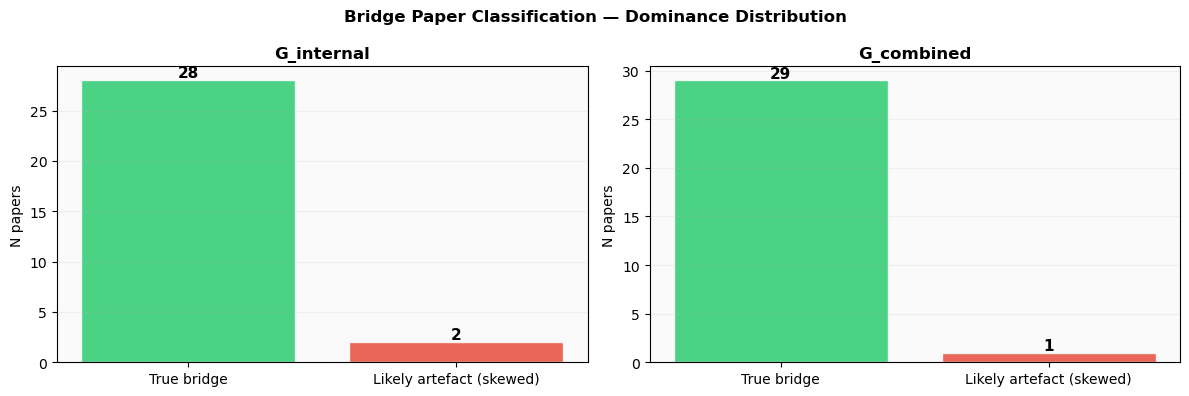

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Bridge Paper Classification — Dominance Distribution',
             fontsize=12, fontweight='bold')
for ax, df, title in [
    (axes[0], df_bridges_int,  'G_internal'),
    (axes[1], df_bridges_comb, 'G_combined'),
]:
    counts = df['Classification'].value_counts()
    colors = ['#e74c3c' if 'artefact' in k else
              '#2ecc71' if 'True' in k else '#95a5a6' for k in counts.index]
    ax.bar(counts.index, counts.values, color=colors, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('N papers')
    ax.grid(axis='y', alpha=0.15)
    ax.set_facecolor('#FAFAFA')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.3, str(v), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Crisp projection and fate analysis

To compare ANGEL with crisp algorithms and run fate analysis, project overlap to a disjoint partition:
each multi-membership node is assigned to the community where it has the largest neighbour support.

In [31]:
def crisp_assignment(graph, clustering):
    """Convert overlapping to disjoint: assign each node to densest community."""
    comm_sets = [set(c) for c in clustering.communities]
    node_to_comms = clustering.to_node_community_map()
    final = {}
    for node, comms in node_to_comms.items():
        if len(comms) == 1:
            final[node] = comms[0]
        else:
            neighbours = set(graph.neighbors(node))
            final[node] = max(comms, key=lambda cid: len(neighbours & comm_sets[cid]))
    clean = defaultdict(list)
    for node, cid in final.items():
        clean[cid].append(node)
    return NodeClustering(list(clean.values()), graph=graph, method_name='angel_crisp')

angel_crisp_internal = crisp_assignment(G_internal_undir, angel_internal)
angel_crisp_combined = crisp_assignment(G_combined, angel_combined)
print(f'Crisp communities — G_internal: {len(angel_crisp_internal.communities):,}')
print(f'Crisp communities — G_combined: {len(angel_crisp_combined.communities):,}')

Crisp communities — G_internal: 1,494
Crisp communities — G_combined: 1,244


### Fate analysis - impact of BC edges (crisp ANGEL)

Each community in `angel_crisp_internal` is classified by its outcome in `angel_crisp_combined`.

| Fate | Rule | Meaning |
|---|---|---|
| stable | best Jaccard >= 0.50 | mostly preserved |
| merged | >=2 internal communities map to one combined | unified by BC |
| split | one internal maps to >=2 combined | fragmented by BC |
| dissolved | best Jaccard < 0.20 | no clear counterpart |
| partial | otherwise | mixed reshaping |

Only communities with size >= 50 are analyzed to avoid micro-community noise.

Cross-domain merge: merged components have different dominant FOS labels (L2).

In [33]:
def _entropy(labels):
    _, counts = np.unique(labels, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log(p + 1e-12))

def variation_of_information(labels_a, labels_b):
    return (_entropy(labels_a) + _entropy(labels_b)
            - 2.0 * mutual_info_score(labels_a, labels_b))

def _partition_to_sets(partition, allowed_nodes=None, min_size=1):
    result = []
    for comm in partition.communities:
        s = set(comm)
        if allowed_nodes is not None:
            s &= allowed_nodes
        if len(s) >= min_size:
            result.append(s)
    return result

def get_top_labels(comm, G, attr='FOS', level='sub', top_k=3):
    counter = Counter()
    for node in comm:
        counter.update(parse_labels(G.nodes[node].get(attr), level=level))
    total = sum(counter.values())
    if not total:
        return 'N/A'
    return ' | '.join(f"{k} ({v/total:.0%})" for k, v in counter.most_common(top_k))


def classify_community_fates(part_a, part_b, G,
                              name_a='A', name_b='B',
                              stable_thr=0.5, dissolved_thr=0.20,
                              min_size=50, attr='FOS', level='sub'):
    common = ({n for c in part_a.communities for n in c}
              & {n for c in part_b.communities for n in c})
    a_sets = _partition_to_sets(part_a, common, min_size)
    b_sets = _partition_to_sets(part_b, common, min_size)

    b_to_a_groups = defaultdict(list)
    rows = []

    for a_id, A in enumerate(a_sets):
        overlap = {b_id: len(A & B) / len(A | B)
                   for b_id, B in enumerate(b_sets) if A & B}
        if not overlap:
            rows.append({'a_id': a_id, 'size_a': len(A),
                         'best_jacc': 0.0, 'best_b_id': None,
                         'n_b_touched': 0, 'top_b_frac': 0.0,
                         'top_fos': get_top_labels(A, G, attr=attr, level=level),
                         'fate': 'dissolved'})
            continue
        best_b = max(overlap, key=overlap.get)
        top_b_frac = len(A & b_sets[best_b]) / len(A)
        n_touched = sum(1 for v in overlap.values() if v > 0.05)
        b_to_a_groups[best_b].append(a_id)
        rows.append({'a_id': a_id, 'size_a': len(A),
                     'best_jacc': round(overlap[best_b], 4), 'best_b_id': best_b,
                     'n_b_touched': n_touched,
                     'top_b_frac': round(top_b_frac, 3),
                     'top_fos': get_top_labels(A, G, attr=attr, level=level),
                     'fate': '__pending__'})

    df = pd.DataFrame(rows)
    b_group_size = df['best_b_id'].map(
        lambda bid: len(b_to_a_groups[bid]) if bid is not None else 0
    )
    df['fate'] = np.select(
        [df['fate'] == 'dissolved',
         df['best_jacc'] >= stable_thr,
         b_group_size > 1,
         (df['n_b_touched'] >= 2) & (df['top_b_frac'] < 0.70),
         df['best_jacc'] < dissolved_thr],
        ['dissolved', 'stable', 'merged', 'split', 'dissolved'],
        default='partial',
    )

    merge_events = []
    for b_id, a_ids in b_to_a_groups.items():
        if len(a_ids) < 2:
            continue
        event_comms = [a_sets[i] for i in a_ids]
        fos_profiles = [get_top_labels(c, G, attr=attr, top_k=2, level=level)
                        for c in event_comms]
        b_fos = get_top_labels(b_sets[b_id], G, attr=attr, top_k=3, level=level)
        unique_dom = len({p.split(' | ')[0].split(' (')[0] for p in fos_profiles})
        merge_events.append({
            'b_id': b_id, 'b_size': len(b_sets[b_id]),
            'n_merged': len(a_ids), 'a_sizes': [len(c) for c in event_comms],
            'fos_profiles': fos_profiles, 'b_fos': b_fos,
            'cross_domain': unique_dom > 1,
        })
    merge_events.sort(key=lambda x: x['b_size'], reverse=True)

    map_a = {n: cid for cid, s in enumerate(a_sets) for n in s}
    map_b = {n: cid for cid, s in enumerate(b_sets) for n in s}
    common_nodes = sorted(set(map_a) & set(map_b))
    la = np.array([map_a[n] for n in common_nodes])
    lb = np.array([map_b[n] for n in common_nodes])
    nmi = normalized_mutual_info_score(la, lb, average_method='arithmetic')
    vi = variation_of_information(la, lb)

    print(f'\n{"="*60}')
    print(f'  Fate Analysis: {name_a} -> {name_b}')
    print(f'{"="*60}')
    print(f'  Communities analysed (>={min_size} nodes): {len(df)}')
    print(f'  NMI: {nmi:.4f}  |  VI: {vi:.4f}')
    for fate, grp in df.groupby('fate'):
        pct = len(grp) / len(df) * 100
        print(f'    {fate:<12s} {len(grp):>4d}  ({pct:5.1f}%)  {"#" * int(pct/2)}')
    n_cross = sum(e['cross_domain'] for e in merge_events)
    print(f'\n  Merge events: {len(merge_events)}  |  Cross-domain: {n_cross}')

    return df, merge_events, {'NMI': nmi, 'VI': vi}


def print_merge_report(merge_events, top_n=10):
    print(f'\n{"="*65}')
    print(f'  TOP {top_n} MERGE EVENTS  (components >= 50 nodes)')
    print(f'{"="*65}')
    for i, ev in enumerate(merge_events[:top_n]):
        tag = '[cross-domain]' if ev['cross_domain'] else '[same-domain]'
        print(f'\n  [{i+1}] {tag}  -  {ev["n_merged"]} comms -> 1  (merged size: {ev["b_size"]})')
        print(f'       Merged FOS: {ev["b_fos"]}')
        for j, (fos, sz) in enumerate(zip(ev['fos_profiles'], ev['a_sizes'])):
            print(f'         C{j+1} (n={sz:>5d}): {fos}')

In [34]:
df_fates_angel, merge_events_angel, global_angel = classify_community_fates(
    part_a   = angel_crisp_internal,
    part_b   = angel_crisp_combined,
    G        = G_combined,
    name_a   = 'ANGEL_crisp/Internal',
    name_b   = 'ANGEL_crisp/Combined',
    attr     = 'FOS',
    level    = 'sub',
    min_size = FATE_MIN_SIZE,
)


  Fate Analysis: ANGEL_crisp/Internal -> ANGEL_crisp/Combined
  Communities analysed (>=50 nodes): 139
  NMI: 0.8828  |  VI: 0.9501
    dissolved       2  (  1.4%)  
    merged         56  ( 40.3%)  ####################
    partial        11  (  7.9%)  ###
    split           1  (  0.7%)  
    stable         69  ( 49.6%)  ########################

  Merge events: 16  |  Cross-domain: 6


In [35]:
print_merge_report(merge_events_angel, top_n=10)


  TOP 10 MERGE EVENTS  (components >= 50 nodes)

  [1] [same-domain]  -  7 comms -> 1  (merged size: 3676)
       Merged FOS: 0103 physical sciences (93%) | 0302 clinical medicine (3%) | 0105 earth and related environmental sciences (1%)
         C1 (n= 2276): 0103 physical sciences (94%) | 0302 clinical medicine (3%)
         C2 (n=  526): 0103 physical sciences (97%) | 0301 basic medicine (1%)
         C3 (n=  143): 0103 physical sciences (98%) | 0504 sociology (1%)
         C4 (n=  110): 0103 physical sciences (99%) | 0202 electrical engineering, electronic engineering, information engineering (1%)
         C5 (n=  107): 0103 physical sciences (99%) | 0302 clinical medicine (1%)
         C6 (n=   70): 0103 physical sciences (73%) | 0302 clinical medicine (27%)
         C7 (n=   65): 0103 physical sciences (100%)

  [2] [cross-domain]  -  12 comms -> 1  (merged size: 2391)
       Merged FOS: 0302 clinical medicine (74%) | 0301 basic medicine (18%) | 0303 health sciences (7%)
       

## Semantic purity

In [36]:
def compute_semantic_purity(clustering, G, attr='FOS', level='macro', min_size=10):
    def _gini(counts):
        if len(counts) == 0:
            return 0.0
        s = np.sort(counts.astype(float))
        n = len(s)
        return (2 * np.sum(np.arange(1, n+1) * s)) / (n * s.sum()) - (n+1) / n

    entropies, ginis, sizes = [], [], []
    for comm in clustering.communities:
        if len(comm) < min_size:
            continue
        labels = []
        for node in comm:
            labels.extend(parse_labels(G.nodes[node].get(attr), level=level))
        if not labels:
            continue
        _, counts = np.unique(labels, return_counts=True)
        probs = counts / counts.sum()
        H = scipy_entropy(probs, base=2)
        H_max = np.log2(len(counts)) if len(counts) > 1 else 1.0
        entropies.append(H / H_max if H_max > 0 else 0.0)
        ginis.append(_gini(counts))
        sizes.append(len(comm))

    sizes = np.array(sizes)
    total = sizes.sum()
    return {
        'entropy': (np.array(entropies) * sizes).sum() / total,
        'gini':    (np.array(ginis) * sizes).sum() / total,
        'n_comms': len(sizes),
    }


def print_purity_comparison(clust_int, clust_comb, G_int, G_comb, min_size=10):
    print("\n" + "=" * 80)
    print("SEMANTIC PURITY ANALYSIS")
    print("=" * 80)
    for key, attr, level in [('FOS_L2', 'FOS', 'macro'), ('FOS', 'FOS', 'sub'), ('SDG', 'SDG', 'all')]:
        p_int  = compute_semantic_purity(clust_int,  G_int,  attr=attr, level=level, min_size=min_size)
        p_comb = compute_semantic_purity(clust_comb, G_comb, attr=attr, level=level, min_size=min_size)
        de = p_comb['entropy'] - p_int['entropy']
        dg = p_comb['gini'] - p_int['gini']
        e_verdict = "WORSE" if de > 0.01 else ("BETTER" if de < -0.01 else "SAME")
        g_verdict = "BETTER" if dg > 0.01 else ("WORSE" if dg < -0.01 else "SAME")
        print(f"\n{key}:")
        print(f"  Internal  | Entropy: {p_int['entropy']:.4f} | Gini: {p_int['gini']:.4f} | Comms: {p_int['n_comms']}")
        print(f"  Combined  | Entropy: {p_comb['entropy']:.4f} | Gini: {p_comb['gini']:.4f} | Comms: {p_comb['n_comms']}")
        print(f"  Delta Combined vs Internal: Entropy {de:+.4f} ({e_verdict}) | Gini {dg:+.4f} ({g_verdict})")
    print("=" * 80)

print_purity_comparison(angel_internal, angel_combined, G_internal_undir, G_combined)


SEMANTIC PURITY ANALYSIS

FOS_L2:
  Internal  | Entropy: 0.3802 | Gini: 0.3620 | Comms: 733
  Combined  | Entropy: 0.3731 | Gini: 0.5078 | Comms: 662
  Delta Combined vs Internal: Entropy -0.0072 (SAME) | Gini +0.1458 (BETTER)

FOS:
  Internal  | Entropy: 0.5529 | Gini: 0.5208 | Comms: 733
  Combined  | Entropy: 0.5213 | Gini: 0.6461 | Comms: 662
  Delta Combined vs Internal: Entropy -0.0315 (BETTER) | Gini +0.1253 (BETTER)

SDG:
  Internal  | Entropy: 0.6174 | Gini: 0.5427 | Comms: 714
  Combined  | Entropy: 0.5784 | Gini: 0.6259 | Comms: 658
  Delta Combined vs Internal: Entropy -0.0389 (BETTER) | Gini +0.0832 (BETTER)


### Summary - ANGEL

- ANGEL adds an overlap-specific view: coverage and multi-membership alongside community quality.
- Parameter calibration (`threshold`, `min_community_size`) is required before interpretation.
- BC impact should be read on two axes: higher coverage and higher overlap among covered nodes.
- Bridge analysis distinguishes true interdisciplinary candidates from structural artefacts.
- Crisp projection enables direct fate comparison with Leiden and InfoMap.
- Fate analysis (`size >=50`) quantifies stable/merged/split dynamics after BC insertion.
- Semantic purity (entropy and Gini) supports interpretation of topical consolidation vs fragmentation.